In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("D:\sales_analyst_project\data\clean_sales_data.csv")

In [9]:
#KPI
total_revenue = df['revenue'].sum()
total_orders = df['invoice_no'].nunique()
total_customers = df['customer_id'].nunique()
aov = df.groupby('invoice_no')['revenue'].sum().mean()

total_revenue, total_orders, total_customers, aov

(1630006.1399999997, 3385, 1647, 481.5380029542098)

In [12]:
# time trend analysis
df['invoice_date'] = pd.to_datetime(
    df['invoice_date'],
    dayfirst=True
)

In [17]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['month'] = df['invoice_date'].dt.to_period('M')

monthly_revenue = df.groupby('month')['revenue'].sum()
monthly_revenue


month
2009-12    686654.16
2010-01    557319.07
2010-02    386032.91
Freq: M, Name: revenue, dtype: float64

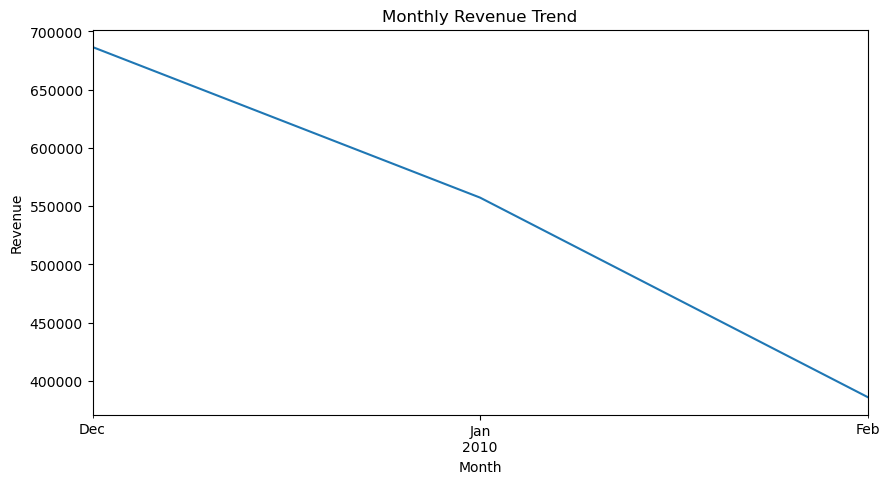

In [19]:
# plot 1
monthly_revenue.plot(
    title="Monthly Revenue Trend",
    figsize=(10,5)
)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [20]:
# country level performance

country_revenue = (
    df.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
country_revenue


country
United Kingdom\r    1335676.74
EIRE\r                99674.55
Netherlands\r         59659.60
Germany\r             30147.70
Denmark\r             29118.16
France\r              22808.01
Spain\r               12640.46
Greece\r               5409.30
Belgium\r              5290.62
Cyprus\r               4383.99
Name: revenue, dtype: float64

) missing from current font.b\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


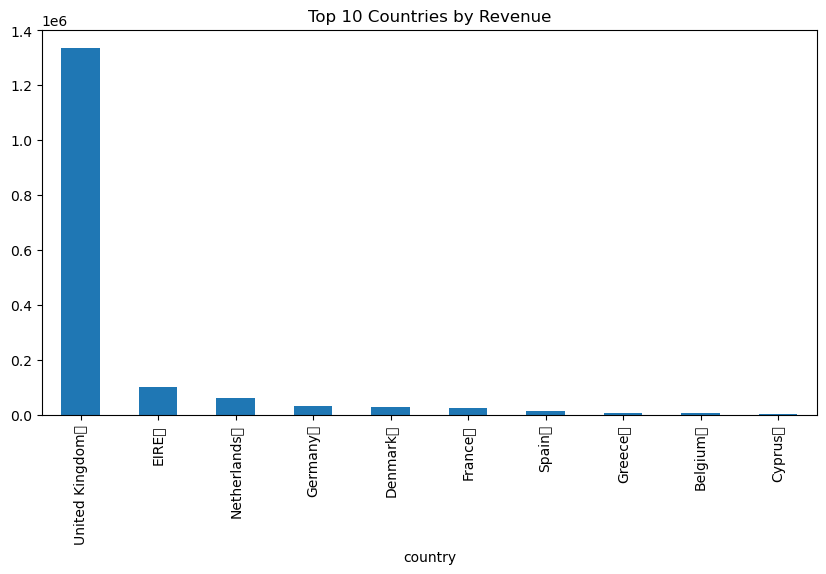

In [ ]:
# plot 2
 
country_revenue.plot(
    kind='bar',
    title="Top 10 Countries by Revenue",
    figsize=(10,5)
)
plt.show()


In [4]:
# customer concentration analysis

top_customer=(df.groupby('customer_id')['revenue']
              .sum()
              .sort_values(ascending=False)
              .head(10))
top_customer

customer_id
18102    91637.96
14156    71887.07
14646    58551.39
13694    41683.05
13902    27228.96
14911    25547.89
15311    20729.90
17949    18265.68
15061    17860.50
17511    15763.00
Name: revenue, dtype: float64

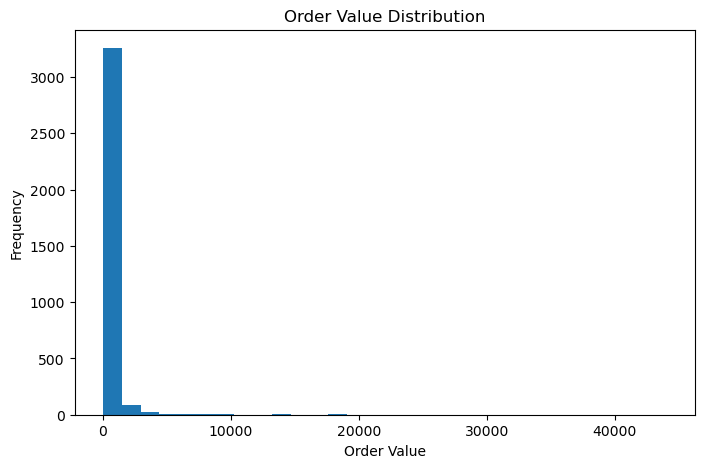

In [ ]:
# plot 3

order_values = df.groupby('invoice_no')['revenue'].sum()
order_values.plot(
    kind='hist',
    bins=30,
    title='Order Value Distribution',
    figsize=(8,5)
)
plt.xlabel("Order Value")
plt.show()
